In [10]:
import pandas as pd
import time
import random
import sys
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files
import pandas as pd
uploaded = files.upload()



Saving clean_dataset.csv to clean_dataset.csv


In [12]:
sys.setrecursionlimit(20000)


def insertion_sort(arr):
    A = arr.copy()
    for i in range(1, len(A)):
        key = A[i]
        j = i - 1
        while j >= 0 and key < A[j]:
            A[j + 1] = A[j]
            j -= 1
        A[j + 1] = key
    return A


def heapify(arr, n, i):
    largest = i
    l = 2 * i + 1
    r = 2 * i + 2
    if l < n and arr[i] < arr[l]:
        largest = l
    if r < n and arr[largest] < arr[r]:
        largest = r
    if largest != i:
        arr[i], arr[largest] = arr[largest], arr[i]
        heapify(arr, n, largest)

def heap_sort(arr):
    A = arr.copy()
    n = len(A)
    for i in range(n // 2 - 1, -1, -1):
        heapify(A, n, i)
    for i in range(n - 1, 0, -1):
        A[i], A[0] = A[0], A[i]
        heapify(A, i, 0)
    return A


def quick_sort(arr):
    A = arr.copy()
    _quick_sort_helper(A, 0, len(A) - 1)
    return A

def _quick_sort_helper(arr, low, high):
    if low < high:
        pivot_index = _partition(arr, low, high)
        _quick_sort_helper(arr, low, pivot_index - 1)
        _quick_sort_helper(arr, pivot_index + 1, high)

def _partition(arr, low, high):
    pivot = arr[high]
    i = low - 1
    for j in range(low, high):
        if arr[j] <= pivot:
            i += 1
            arr[i], arr[j] = arr[j], arr[i]
    arr[i + 1], arr[high] = arr[high], arr[i + 1]
    return i + 1

file_name = 'clean_dataset.csv'
column_name = 'rating'

try:
    df = pd.read_csv(file_name)
    full_dataset_list = df[column_name].dropna().tolist()
    print(f"Dataset is downloaded successfully! Total elements: {len(full_dataset_list)}\n")
except Exception as e:
    print("Dataset will be generated automatically. Please make sure your file is clean and free of errors.")

    full_dataset_list = [random.uniform(1.0, 1000.0) for _ in range(11000)]

sizes = [200, 500, 1000, 2200, 4300, 5500, 6700, 10000]

heap_times = []
quick_times = []
insertion_times = []
actual_sizes = []

for size in sizes:
    if size > len(full_dataset_list):
        break
    actual_sizes.append(size)


    sample_data = full_dataset_list[:size]

    # Heap Sort
    start = time.time()
    heap_sort(sample_data)
    end = time.time()
    heap_times.append((end - start) * 1000)

    # Quick Sort
    start = time.time()
    quick_sort(sample_data)
    end = time.time()
    quick_times.append((end - start) * 1000)

    # Insertion Sort
    start = time.time()
    insertion_sort(sample_data)
    end = time.time()
    insertion_times.append((end - start) * 1000)

results_df = pd.DataFrame({
    'Input Size (n)': actual_sizes,
    'Algorithm 1 (Heap) Time (ms)': heap_times,
    'Algorithm 2 (Quick) Time (ms)': quick_times,
    'Algorithm 3 (Insertion) Time (ms)': insertion_times
})

pd.options.display.float_format = '{:,.3f}'.format

print("Final Results:")
print(results_df.to_string(index=False))

Dataset is downloaded successfully! Total elements: 18598

Final Results:
 Input Size (n)  Algorithm 1 (Heap) Time (ms)  Algorithm 2 (Quick) Time (ms)  Algorithm 3 (Insertion) Time (ms)
            200                         0.128                          1.012                              0.215
            500                         0.382                          6.090                              1.958
           1000                         0.753                         25.368                              8.370
           2200                         1.836                        131.705                             42.840
           4300                         4.187                        523.228                            176.612
           5500                         5.404                        855.136                            257.302
           6700                         6.263                      1,286.449                            406.783
          10000               

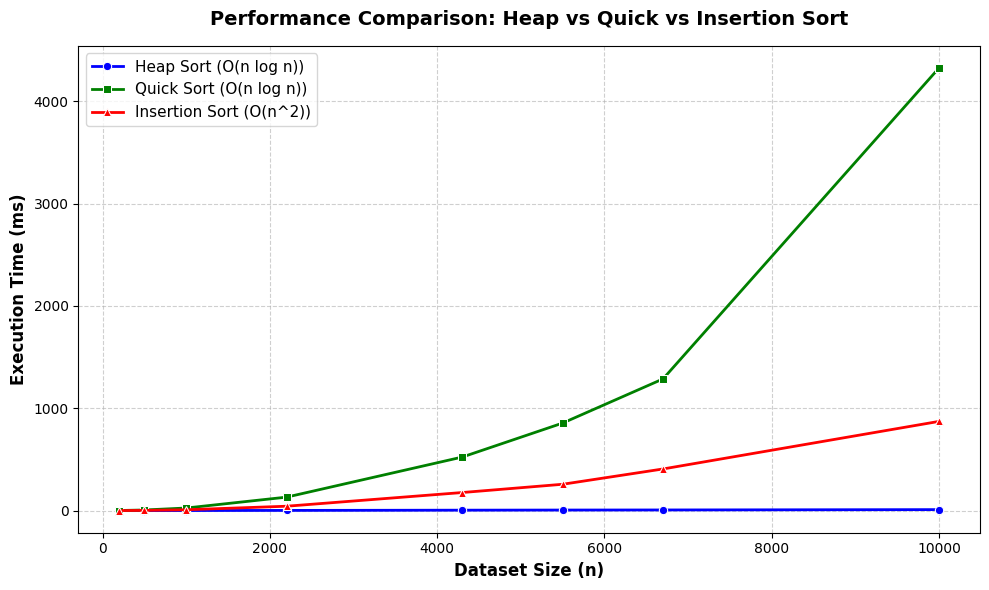

In [13]:
plt.figure(figsize=(10, 6))

sns.lineplot(x=actual_sizes, y=heap_times, marker='o', label='Heap Sort (O(n log n))', color='blue', linewidth=2)
sns.lineplot(x=actual_sizes, y=quick_times, marker='s', label='Quick Sort (O(n log n))', color='green', linewidth=2)
sns.lineplot(x=actual_sizes, y=insertion_times, marker='^', label='Insertion Sort (O(n^2))', color='red', linewidth=2)

plt.title('Performance Comparison: Heap vs Quick vs Insertion Sort', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Dataset Size (n)', fontsize=12, fontweight='bold')
plt.ylabel('Execution Time (ms)', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)


plt.tight_layout()
plt.show()